In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
from PIL import Image

In [ ]:
dataset_path = "/content/drive/MyDrive/Colab Notebooks/DSC4900_project_portfolio/wildcats"
print("Dataset path exists:", os.path.exists(dataset_path))
print("Folders inside dataset:")
print(os.listdir(dataset_path))

Dataset path exists: True
Folders inside dataset:
['colab files', 'train', 'val', 'wildcat image classification.gdoc']


In [ ]:
base_path = "/content/drive/MyDrive/Colab Notebooks/DSC4900_project_portfolio/wildcats"
train_path = os.path.join(base_path, "train")
val_path = os.path.join(base_path, "val")
# double checking the file exploration is good to go
print("Base path exists:", os.path.exists(base_path))
print("Train path exists:", os.path.exists(train_path))
print("Val path exists:", os.path.exists(val_path))

Base path exists: True
Train path exists: True
Val path exists: True


In [ ]:
print("Train folders:", os.listdir(train_path))
print("Val folders:", os.listdir(val_path))

Train folders: ['pallas', 'cheetah', 'lynx', 'lion']
Val folders: ['lion', 'lynx', 'cheetah', 'pallas']


In [ ]:
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")
# train counts by species
print("TRAIN COUNTS")
for class_name in sorted(os.listdir(train_path)):
    class_folder = os.path.join(train_path, class_name)
    if os.path.isdir(class_folder):
        count = len([f for f in os.listdir(class_folder) if f.lower().endswith(valid_extensions)])
        print(f"{class_name}: {count}")
# val counts by species
print("\nVAL COUNTS")
for class_name in sorted(os.listdir(val_path)):
    class_folder = os.path.join(val_path, class_name)
    if os.path.isdir(class_folder):
        count = len([f for f in os.listdir(class_folder) if f.lower().endswith(valid_extensions)])
        print(f"{class_name}: {count}")

TRAIN COUNTS
cheetah: 30
lion: 30
lynx: 30
pallas: 15

VAL COUNTS
cheetah: 10
lion: 10
lynx: 10
pallas: 5


In [ ]:
img_height = 180
img_width = 180
batch_size = 32
# train
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(img_height, img_width),
    batch_size=batch_size
)
# val
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 105 files belonging to 4 classes.
Found 35 files belonging to 4 classes.


In [ ]:
class_names = train_ds.class_names
print("Class names:", class_names)

Class names: ['cheetah', 'lion', 'lynx', 'pallas']


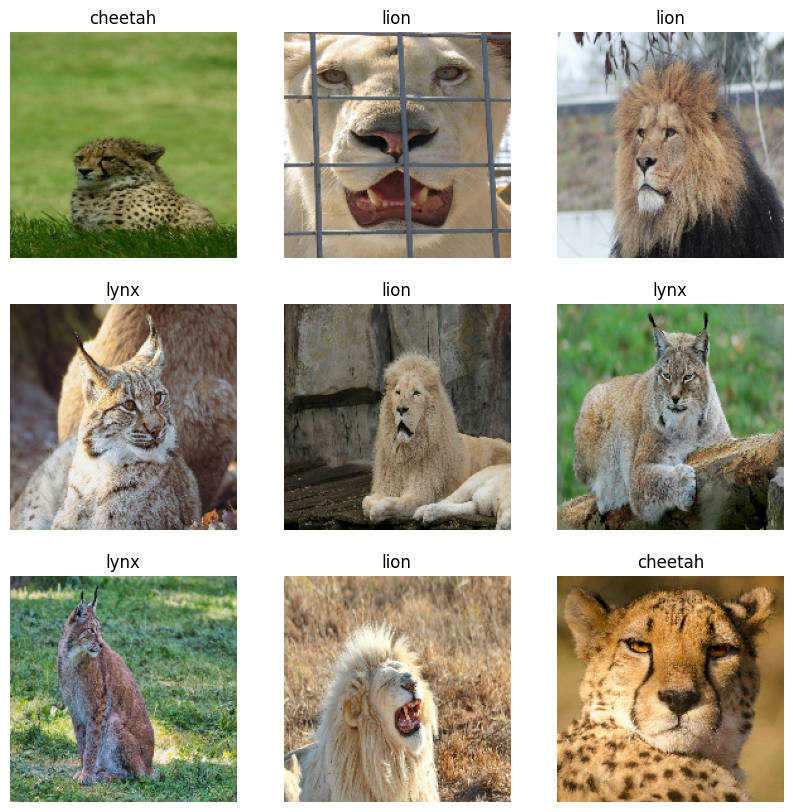

In [ ]:
# example image set pulled from larger pools of data within drive
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
# data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

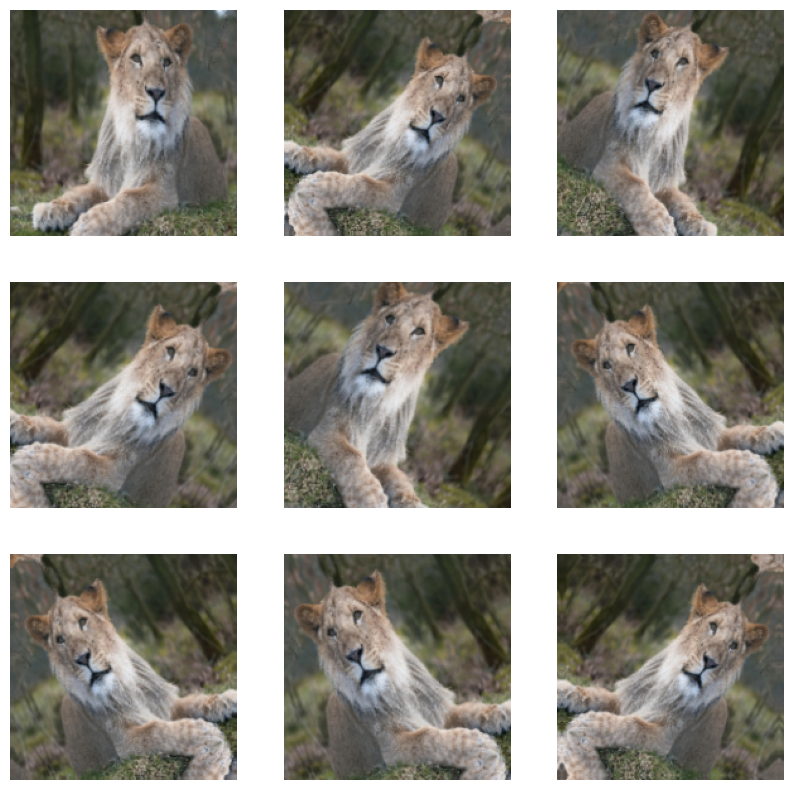

In [ ]:
# example batch of data augmentation
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    first_image = images[0]
    for i in range(9):
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.axis("off")

plt.show()

In [ ]:
# create cnn model
num_classes = len(class_names)

model = keras.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes)
])

In [ ]:
# train model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,929,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,023,748 (30.61 MB)

 Trainable params: 8,023,748 (30.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 6s/step - accuracy: 0.2952 - loss: 3.1913 - val_accuracy: 0.2857 - val_loss: 1.4111
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.2857 - loss: 1.3970 - val_accuracy: 0.2571 - val_loss: 1.3817
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.2762 - loss: 1.3520 - val_accuracy: 0.2857 - val_loss: 1.3746
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.2190 - loss: 1.4207 - val_accuracy: 0.2857 - val_loss: 1.3318
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.3714 - loss: 1.3621 - val_accuracy: 0.3429 - val_loss: 1.3309
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.4286 - loss: 1.3420 - val_accuracy: 0.3429 - val_loss: 1.2861
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3810 - loss: 1.3245 - val_accuracy: 0.4000 - val_loss: 1.2807
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.4095 - loss: 1.2801 - val_accuracy: 0.3714 - val_loss: 1.2023
Epoch 9/10
4/

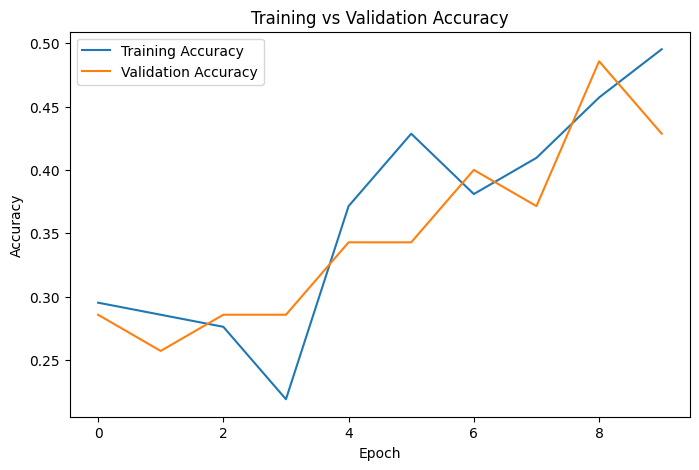

In [ ]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

epochs_range = range(epochs)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

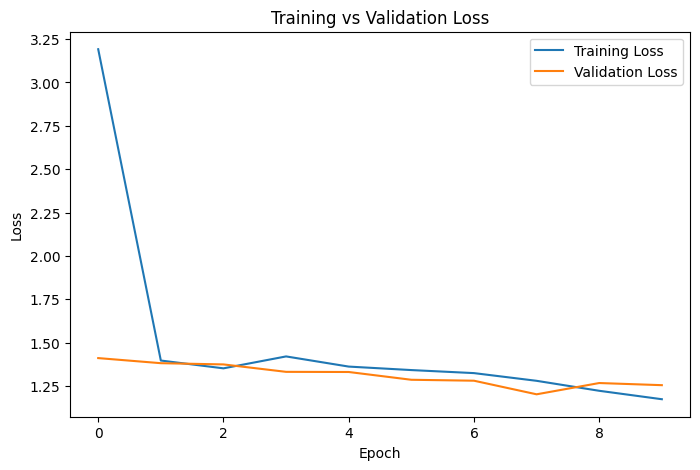

In [ ]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [ ]:
val_loss, val_accuracy = model.evaluate(val_ds)
print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.4286 - loss: 1.2550
Validation Loss: 1.2549852132797241
Validation Accuracy: 0.4285714328289032


In [ ]:
model_save_path = "/content/drive/MyDrive/Colab Notebooks/DSC4900_project_portfolio/wildcat_cnn_model.h5"
model.save(model_save_path)
print("Model saved to:", model_save_path)

Model saved to: /content/drive/MyDrive/Colab Notebooks/DSC4900_project_portfolio/wildcat_cnn_model.h5


In [ ]:
class_names_save_path = "/content/drive/MyDrive/Colab Notebooks/DSC4900_project_portfolio/wildcat_class_names.npy"
np.save(class_names_save_path, np.array(class_names))
print("Class names saved to:", class_names_save_path)

Class names saved to: /content/drive/MyDrive/Colab Notebooks/DSC4900_project_portfolio/wildcat_class_names.npy


Animal CSV from Kaggle

In [ ]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix, accuracy_score
import statsmodels.api as sm
from sklearn.metrics import roc_curve, auc

In [ ]:
# import dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DSC4900_project_portfolio/wildcats/animal planet csv/Animal Dataset.csv')
print(df.head())

             Animal Height (cm) Weight (kg)         Color Lifespan (years)  \
0          Aardvark     105-130       40-65          Grey            20-30   
1          Aardwolf       40-50        8-14  Yellow-brown            10-12   
2  African Elephant     270-310   2700-6000          Grey            60-70   
3      African Lion      80-110     120-250           Tan            10-14   
4  African Wild Dog       75-80       18-36  Multicolored            10-12   

          Diet               Habitat           Predators Average Speed (km/h)  \
0  Insectivore  Savannas, Grasslands       Lions, Hyenas                   40   
1  Insectivore  Grasslands, Savannas     Lions, Leopards                24-30   
2    Herbivore      Savannah, Forest       Lions, Hyenas                   25   
3    Carnivore  Grasslands, Savannas  Hyenas, Crocodiles                   58   
4    Carnivore             Savannahs       Lions, Hyenas                   56   

               Countries Found Conservation 

In [ ]:
df.describe()

,Animal,Height (cm),Weight (kg),Color,Lifespan (years),Diet,Habitat,Predators,Average Speed (km/h),Countries Found,Conservation Status,Family,Gestation Period (days),Top Speed (km/h),Social Structure,Offspring per Birth
count,205,205,205,205,205,205,205,205,205,205,205,205,205,205,205,205
unique,196,162,184,85,93,16,97,113,97,104,12,120,161,71,10,68
top,Blobfish,Up to 30,Up to 0.5,Various,10-15,Carnivore,Rainforests,Not Applicable,Not Applicable,Worldwide,Least Concern,Canidae,Not Applicable,Not Applicable,Solitary,1
freq,2,4,4,14,21,72,31,13,21,19,68,14,12,31,132,81


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Animal                   205 non-null    object
 1   Height (cm)              205 non-null    object
 2   Weight (kg)              205 non-null    object
 3   Color                    205 non-null    object
 4   Lifespan (years)         205 non-null    object
 5   Diet                     205 non-null    object
 6   Habitat                  205 non-null    object
 7   Predators                205 non-null    object
 8   Average Speed (km/h)     205 non-null    object
 9   Countries Found          205 non-null    object
 10  Conservation Status      205 non-null    object
 11  Family                   205 non-null    object
 12  Gestation Period (days)  205 non-null    object
 13  Top Speed (km/h)         205 non-null    object
 14  Social Structure         205 non-null    o

In [ ]:
df.columns

Index(['Animal', 'Height (cm)', 'Weight (kg)', 'Color', 'Lifespan (years)',
       'Diet', 'Habitat', 'Predators', 'Average Speed (km/h)',
       'Countries Found', 'Conservation Status', 'Family',
       'Gestation Period (days)', 'Top Speed (km/h)', 'Social Structure',
       'Offspring per Birth'],
      dtype='object')

Data Cleaning

In [ ]:
# cleaning up numeric columns
def clean_and_convert_numeric(value):
    if pd.isna(value) or value == 'Not Applicable' or value == 'Various' or value == 'Unknown' or value == 'Up to 30':
        return np.nan
    value_str = str(value).replace(',', '') # Remove commas if present
    if '-' in value_str:
        parts = value_str.split('-')
        try:
            return (float(parts[0]) + float(parts[1])) / 2
        except ValueError:
            return np.nan
    else:
        try:
            return float(value_str)
        except ValueError:
            return np.nan

numerical_columns = [
    'Height (cm)', 'Weight (kg)', 'Lifespan (years)', 'Average Speed (km/h)',
    'Gestation Period (days)', 'Top Speed (km/h)', 'Offspring per Birth'
]

for col in numerical_columns:
    df[col] = df[col].apply(clean_and_convert_numeric)

print(df[numerical_columns].head())
print(df[numerical_columns].info())

   Height (cm)  Weight (kg)  Lifespan (years)  Average Speed (km/h)  \
0        117.5         52.5              25.0                  40.0   
1         45.0         11.0              11.0                  27.0   
2        290.0       4350.0              65.0                  25.0   
3         95.0        185.0              12.0                  58.0   
4         77.5         27.0              11.0                  56.0   

   Gestation Period (days)  Top Speed (km/h)  Offspring per Birth  
0                    225.0              40.0                  1.0  
1                     90.0              40.0                  3.5  
2                    650.0              40.0                  1.0  
3                    101.5              80.0                  NaN  
4                     70.0              56.0                 11.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  --

In [ ]:
df_cleaned_numerical = df.dropna(subset=numerical_columns)
print("Original DataFrame shape: {df.shape}")
print("DataFrame shape after dropping NaNs in numerical columns: {df_cleaned_numerical.shape}")
print(df_cleaned_numerical[numerical_columns].info())

Original DataFrame shape: {df.shape}
DataFrame shape after dropping NaNs in numerical columns: {df_cleaned_numerical.shape}
<class 'pandas.core.frame.DataFrame'>
Index: 103 entries, 0 to 203
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Height (cm)              103 non-null    float64
 1   Weight (kg)              103 non-null    float64
 2   Lifespan (years)         103 non-null    float64
 3   Average Speed (km/h)     103 non-null    float64
 4   Gestation Period (days)  103 non-null    float64
 5   Top Speed (km/h)         103 non-null    float64
 6   Offspring per Birth      103 non-null    float64
dtypes: float64(7)
memory usage: 6.4 KB
None


Linear Model

In [ ]:
target = 'Height (cm)'
X = df_cleaned_numerical[numerical_columns].drop(columns=[target])
y = df_cleaned_numerical[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

linear_preds = linear_model.predict(X_test_scaled)

linear_mse = mean_squared_error(y_test, linear_preds)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_preds)

print("Linear Regression")
print("MSE:", linear_mse)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

Linear Regression
MSE: 23991.360872662062
RMSE: 154.8914486750707
R²: -4.314796919806013


The negative R squared means the model does not perform well predictively, likely due to such a small sample size remaining after cleaning the numerical values.

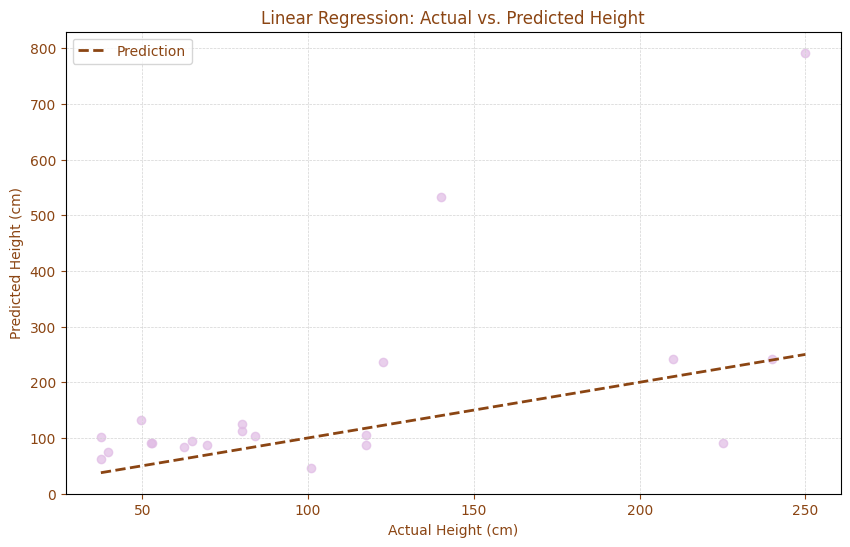

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, linear_preds, alpha=0.7, color='#E0BBE4')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='#8B4513', linestyle='--', lw=2, label='Prediction')
plt.xlabel('Actual Height (cm)', color='#8B4513')
plt.ylabel('Predicted Height (cm)', color='#8B4513')
plt.title('Linear Regression: Actual vs. Predicted Height', color='#8B4513')
plt.legend(labelcolor='#8B4513')
plt.grid(True, color='#D3D3D3', linestyle='--', linewidth=0.5)
plt.tick_params(axis='x', colors='#8B4513')
plt.tick_params(axis='y', colors='#8B4513')
plt.show()

Logistic Regression

In [ ]:
df_class = df_cleaned_numerical.copy()

df_class["large_animal"] = (
    df_class["Height (cm)"] > df_class["Height (cm)"].mean()
).astype(int)

print(df_class["large_animal"].value_counts())

large_animal
0    69
1    34
Name: count, dtype: int64


In [ ]:
X_class = df_class[numerical_columns].drop(columns=[target])
y_class = df_class["large_animal"]

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

scaler_class = StandardScaler()

X_train_class_scaled = scaler_class.fit_transform(X_train_class)
X_test_class_scaled = scaler_class.transform(X_test_class)

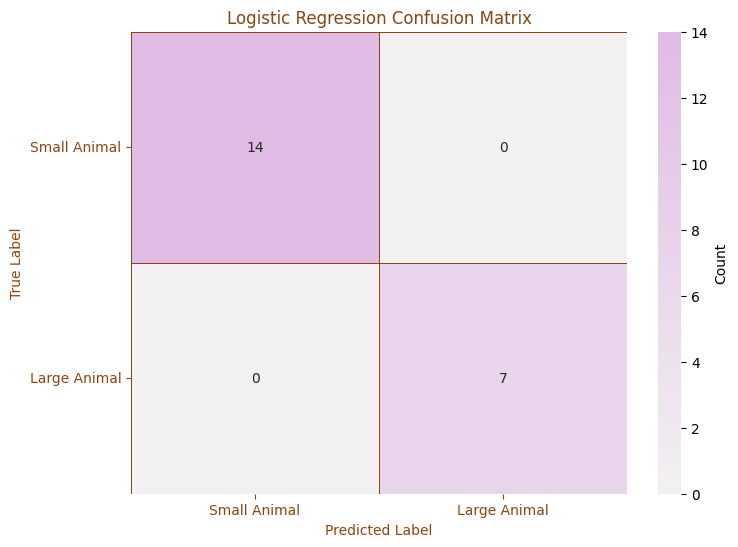

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00         7

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



In [ ]:
logreg_model = LogisticRegression(random_state=42)
logreg_model.fit(X_train_class_scaled, y_train_class)

logreg_preds = logreg_model.predict(X_test_class_scaled)

cm = confusion_matrix(y_test_class, logreg_preds)
# cutesy color scheme!!
pink = '#E0BBE4'
brown = '#8B4513'
light_brown = '#C2B280'

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap=sns.light_palette(pink, as_cmap=True),
            linewidths=.5, linecolor=brown, cbar_kws={'label': 'Count'})

plt.title('Logistic Regression Confusion Matrix', color=brown)
plt.xlabel('Predicted Label', color=brown)
plt.ylabel('True Label', color=brown)
plt.xticks(ticks=[0.5, 1.5], labels=['Small Animal', 'Large Animal'], color=light_brown)
plt.yticks(ticks=[0.5, 1.5], labels=['Small Animal', 'Large Animal'], color=light_brown, rotation=0)
plt.tick_params(axis='x', colors=brown)
plt.tick_params(axis='y', colors=brown)
plt.show()

print("Logistic Regression Classification Report:")
print(classification_report(y_test_class, logreg_preds))

The confusion matrix performs too good/unrealistically well, as it only contains true positives and true negatives, with no Type I or Type II errors. This bizarre perfection is also likely due to the aforementioned sample size struggle.

ROC/AUC

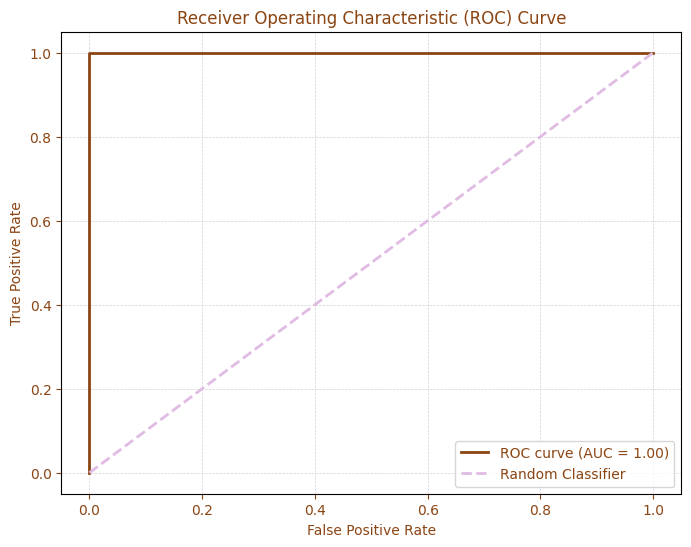

In [ ]:
# predicted probabilities for positive membership class
y_pred_proba = logreg_model.predict_proba(X_test_class_scaled)[:, 1]

# calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test_class, y_pred_proba)

# calculate AUC
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#8B4513', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='#E0BBE4', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate', color='#8B4513')
plt.ylabel('True Positive Rate', color='#8B4513')
plt.title('Receiver Operating Characteristic (ROC) Curve', color='#8B4513')
plt.legend(labelcolor='#8B4513')
plt.grid(True, color='#D3D3D3', linestyle='--', linewidth=0.5)
plt.tick_params(axis='x', colors='#8B4513')
plt.tick_params(axis='y', colors='#8B4513')
plt.show()

As the area under the curve is perfectly at 100%, or 1.0, the model performs too well, meaning that something is off; again, likely small *n*.